# 1. Read data and clean core teachings (try to remove the philosophers name)

In [2]:
import pandas as pd
import re

philosophers = pd.read_csv("../data/philosophers.csv")          # ID,Name
details = pd.read_csv("../data/details.csv")        # ID,...,CoreTeachings,...

df = details.merge(philosophers, on="ID", how="left")   # adds Name column

def clean_core_teachings(row):
    text = str(row["CoreTeachings"])
    name = str(row["Name"])

    # Build a simple pattern: full name and main surname
    parts = [p for p in re.split(r"\s+", name) if p]
    surname = parts[-1] if parts else ""
    # Escape for regex
    name_pat = re.escape(name)
    surname_pat = re.escape(surname)

    # Remove case‑insensitive occurrences of full name and surname
    text = re.sub(name_pat, "", text, flags=re.IGNORECASE)
    if surname:
        text = re.sub(surname_pat, "", text, flags=re.IGNORECASE)

    # Optionally normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["CoreTeachingsClean"] = df.apply(clean_core_teachings, axis=1)

# 2. Sentence Embeddings Using OpenAI API. Save these!

In [ ]:
# api_key = 'your key here or add as env variable'


In [7]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openai import OpenAI
from sklearn.manifold import TSNE
import umap

# ---------- 1. Setup OpenAI client ----------

# Either set OPENAI_API_KEY in your environment, or pass it directly:
client = OpenAI(api_key=api_key)

EMBEDDING_MODEL = "text-embedding-3-small"  # good default

texts = df["CoreTeachingsClean"].tolist()
ids = df["ID"].tolist()

# ---------- 3. Get OpenAI embeddings ----------

embeddings = []

for i, text in enumerate(texts):
    # Optional: print progress
    # if i % 10 == 0:
    #     print(f"Embedding {i+1}/{len(texts)}")
    resp = client.embeddings.create(
        model=EMBEDDING_MODEL,
        input=text
    )
    embeddings.append(resp.data[0].embedding)

embeddings = np.array(embeddings)
print("Embeddings shape:", embeddings.shape)

Embeddings shape: (101, 1536)


## Save them

In [9]:
emb_df = pd.DataFrame({
    "ID": ids,
    "embedding": [emb.tolist() for emb in embeddings]
})
emb_df.to_csv('openai_text_emb_small.csv', index=False)

## ---------- 4. Dimensionality reduction: UMAP and/or t-SNE ----------


/Users/aslakey/Desktop/MapOfPhilosphy/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


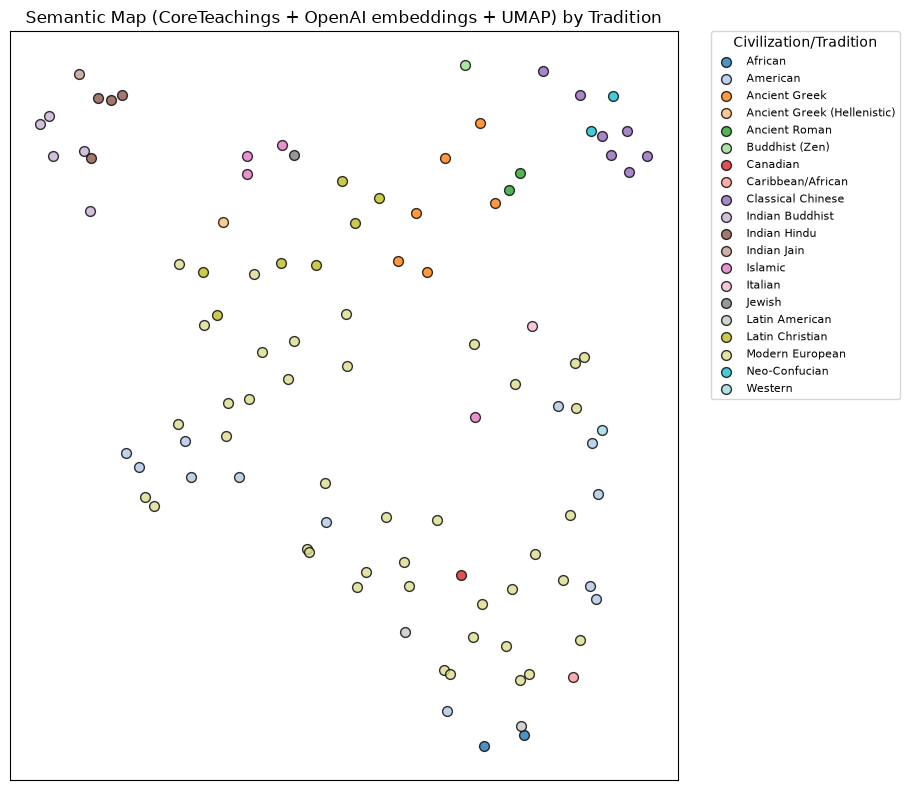

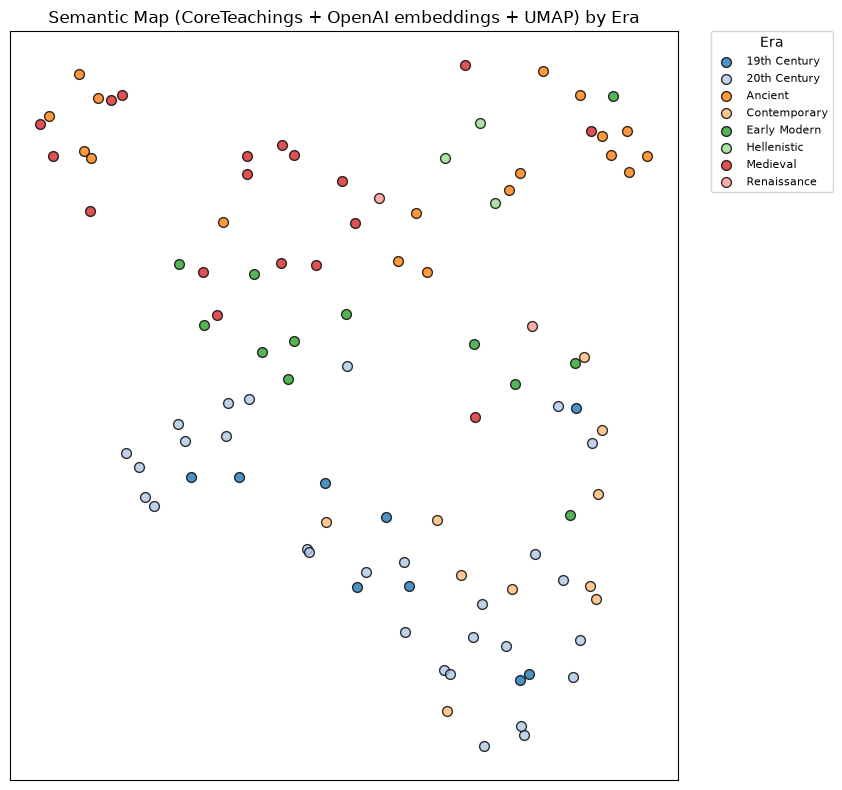

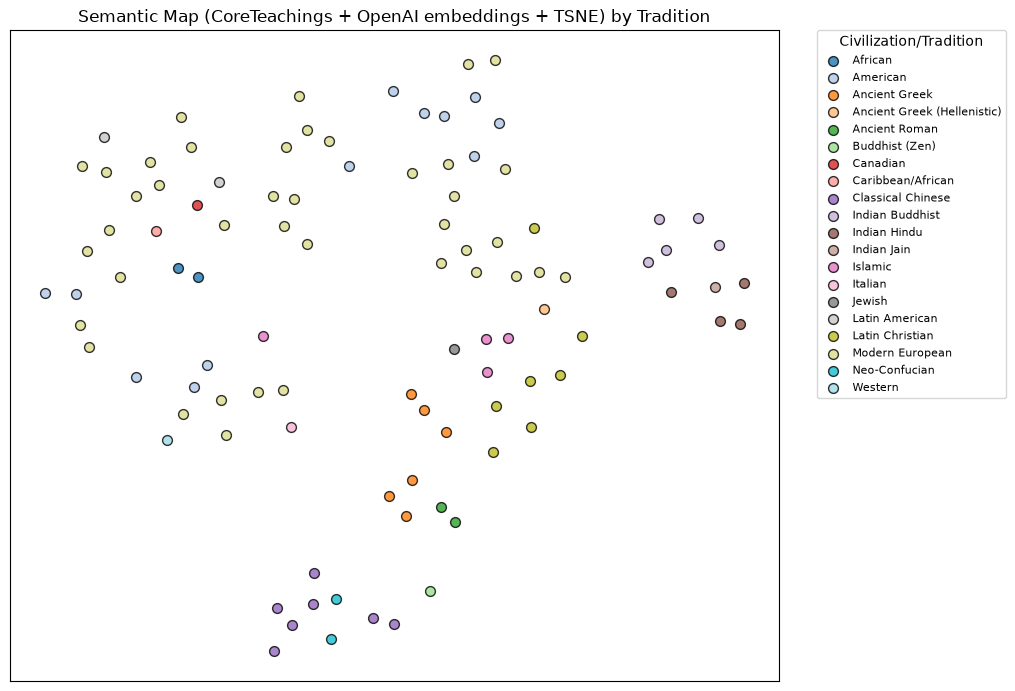

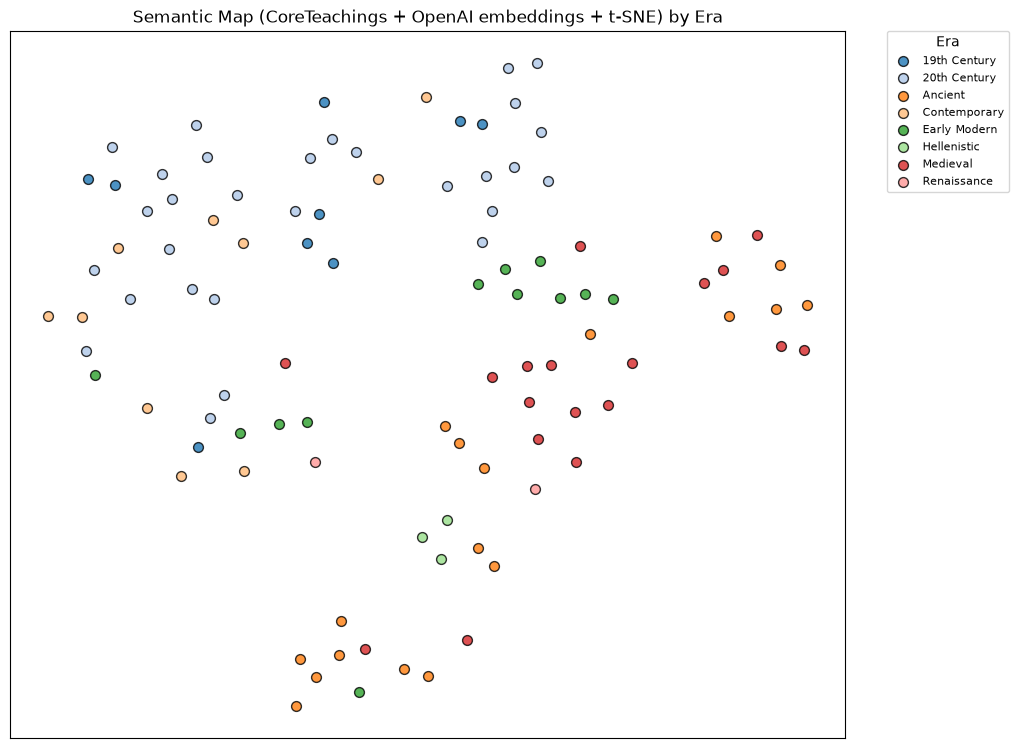

In [13]:

# UMAP (semantic space, usually a good first choice)
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=20,
    min_dist=0.05,
    metric="cosine",
    random_state=42
)
coords_umap = umap_reducer.fit_transform(embeddings)

# t-SNE (alternative view, more "clustered")
tsne = TSNE(
    n_components=2,
    perplexity=12,
    learning_rate=200,
    metric="cosine",
    random_state=42,
    init="pca"
)
coords_tsne = tsne.fit_transform(embeddings)

# ---------- 5. Build DataFrames with coordinates ----------

coords_umap_df = pd.DataFrame(coords_umap, columns=["x", "y"])
coords_umap_df["ID"] = ids

coords_tsne_df = pd.DataFrame(coords_tsne, columns=["x", "y"])
coords_tsne_df["ID"] = ids

# Merge with metadata (Region, Tradition, Era, etc.)
coords_umap_meta = coords_umap_df.merge(df, on="ID", how="left")
coords_tsne_meta = coords_tsne_df.merge(df, on="ID", how="left")

# ---------- 6. Plot helper ----------

def plot_embedding(df, color_by="Civilization/Tradition", title=None, figsize=(10, 8)):
    plt.figure(figsize=figsize)

    values = df[color_by].fillna("Unknown")
    unique_vals = sorted(values.unique())
    cmap = plt.get_cmap("tab20")
    color_map = {val: cmap(i % 20) for i, val in enumerate(unique_vals)}

    for val in unique_vals:
        subset = df[values == val]
        plt.scatter(
            subset["x"],
            subset["y"],
            c=[color_map[val]],
            label=val,
            alpha=0.8,
            edgecolor="k",
            s=50
        )

    plt.xticks([])
    plt.yticks([])
    plt.gca().set_aspect("equal", "box")
    plt.legend(
        title=color_by,
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0.,
        fontsize=8
    )
    plt.title(title or f"Semantic Embedding (colored by {color_by})")
    plt.tight_layout()
    plt.show()

# ---------- 7. Example visualizations ----------

# UMAP, colored by tradition
plot_embedding(
    coords_umap_meta,
    color_by="Civilization/Tradition",
    title="Semantic Map (CoreTeachings + OpenAI embeddings + UMAP) by Tradition"
)

plot_embedding(
    coords_umap_meta,
    color_by="Era",
    title="Semantic Map (CoreTeachings + OpenAI embeddings + UMAP) by Era"
)

# t-SNE, colored by Era
plot_embedding(
    coords_tsne_meta,
    color_by="Civilization/Tradition",
    title="Semantic Map (CoreTeachings + OpenAI embeddings + TSNE) by Tradition"
)

plot_embedding(
    coords_tsne_meta,
    color_by="Era",
    title="Semantic Map (CoreTeachings + OpenAI embeddings + t-SNE) by Era"
)

# # Optional: save coordinates for later use
# coords_umap_meta[["ID", "x", "y"]].to_csv("coords_sem_umap.csv", index=False)
# coords_tsne_meta[["ID", "x", "y"]].to_csv("coords_sem_tsne.csv", index=False)

In [20]:
emb_df.head(2)

,ID,embedding
0,P001,"[0.0225830078125, -0.0304412841796875, -0.0167..."
1,P002,"[0.01325225830078125, 0.004177093505859375, -0..."


In [21]:
coords_umap_meta.merge(emb_df, on='ID')[["ID", "x", "y", "embedding"]].to_csv("../data/coords_semantic_umap.csv", index=False)
coords_tsne_meta.merge(emb_df, on='ID')[["ID", "x", "y", "embedding"]].to_csv("../data/coords_semantic_tsne.csv", index=False)

In [18]:
print("hi")

hi
